In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import itertools
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

sns.set_style("darkgrid")
plt.style.use("dark_background")
sns.set_palette("tab10")

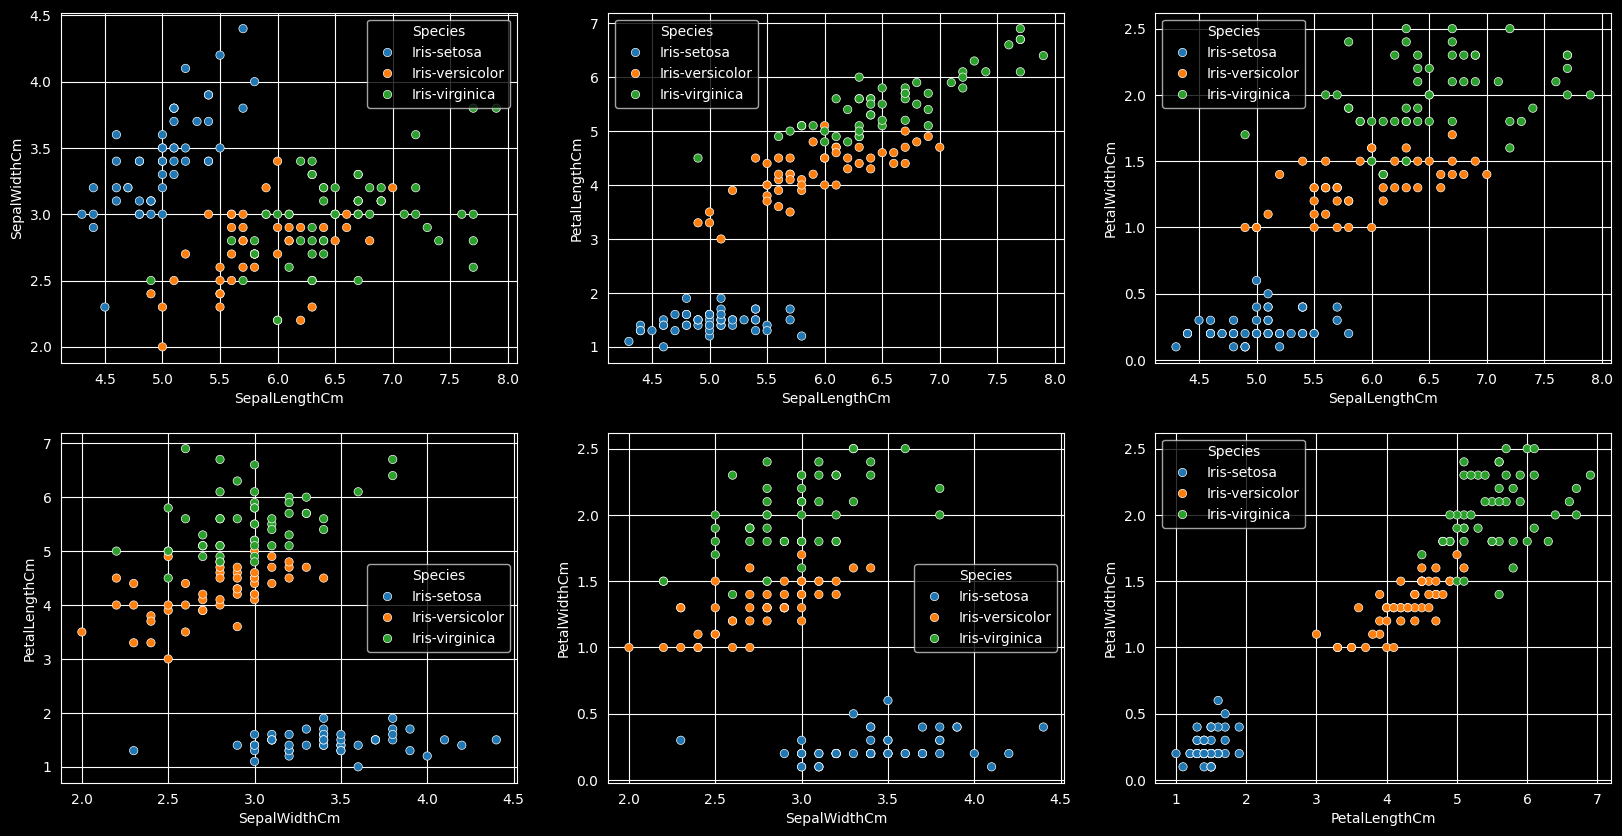

In [2]:
df = pd.read_csv("data/002-iris.csv").set_index("Id")

numeric_colums = df.columns[:-1]
pairs = list(itertools.combinations(numeric_colums, 2))

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

for i, (x, y) in enumerate(pairs):
    sns.scatterplot(data=df, x=x, y=y, hue="Species", ax=axes[i])

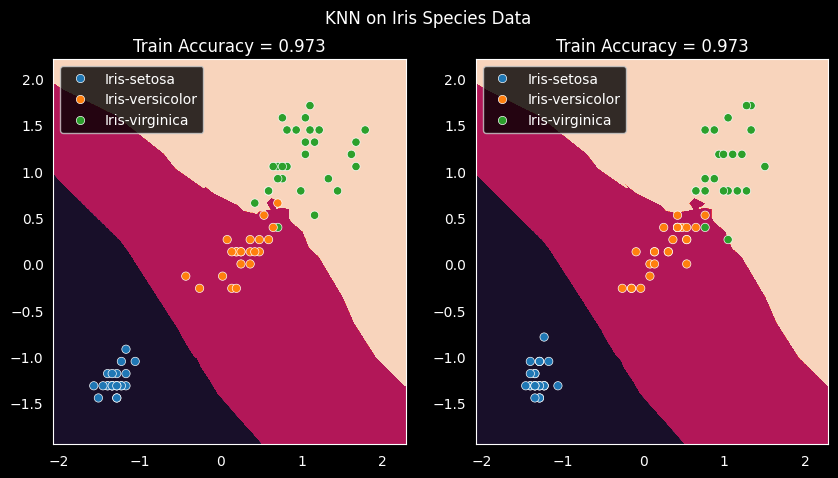

In [3]:
X = df[["PetalLengthCm", "PetalWidthCm"]].to_numpy()
scaler = StandardScaler()
scaler.fit(X)
X = scaler.transform(X)

le = LabelEncoder()
le.fit(df["Species"])
Y = le.transform(df["Species"])

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.5, random_state=67)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, Y_train)

xx, yy = np.meshgrid(
    np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 1000),
    np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 1000),
)
grid_inputs = np.c_[xx.ravel(), yy.ravel()]
grid_outputs = knn.predict(grid_inputs)
grid_outputs = grid_outputs.reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].contourf(xx, yy, grid_outputs)
sns.scatterplot(x=X_train[:, 0], y=X_train[:, 1], hue=le.inverse_transform(Y_train), ax=axes[0])
axes[0].set_title(f"Train Accuracy = {accuracy_score(Y_train, knn.predict(X_train)):.3f}")

axes[1].contourf(xx, yy, grid_outputs)
sns.scatterplot(x=X_test[:, 0], y=X_test[:, 1], hue=le.inverse_transform(Y_test), ax=axes[1])
axes[1].set_title(f"Train Accuracy = {accuracy_score(Y_test, knn.predict(X_test)):.3f}")

plt.suptitle("KNN on Iris Species Data")

plt.show()

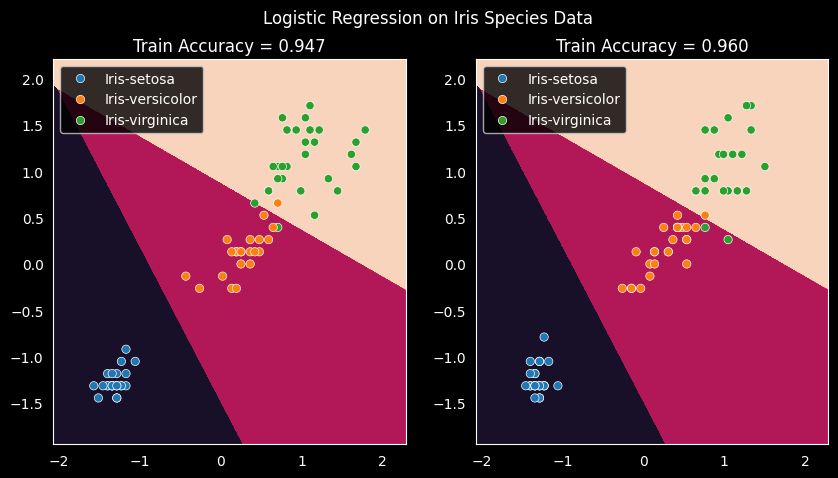

In [4]:
log_res = LogisticRegression(max_iter=50)
log_res.fit(X_train, Y_train)

xx, yy = np.meshgrid(
    np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 1000),
    np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 1000),
)
grid_inputs = np.c_[xx.ravel(), yy.ravel()]
grid_outputs = log_res.predict(grid_inputs)
grid_outputs = grid_outputs.reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].contourf(xx, yy, grid_outputs)
sns.scatterplot(x=X_train[:, 0], y=X_train[:, 1], hue=le.inverse_transform(Y_train), ax=axes[0])
axes[0].set_title(f"Train Accuracy = {accuracy_score(Y_train, log_res.predict(X_train)):.3f}")

axes[1].contourf(xx, yy, grid_outputs)
sns.scatterplot(x=X_test[:, 0], y=X_test[:, 1], hue=le.inverse_transform(Y_test), ax=axes[1])
axes[1].set_title(f"Train Accuracy = {accuracy_score(Y_test, log_res.predict(X_test)):.3f}")

plt.suptitle("Logistic Regression on Iris Species Data")

plt.show()

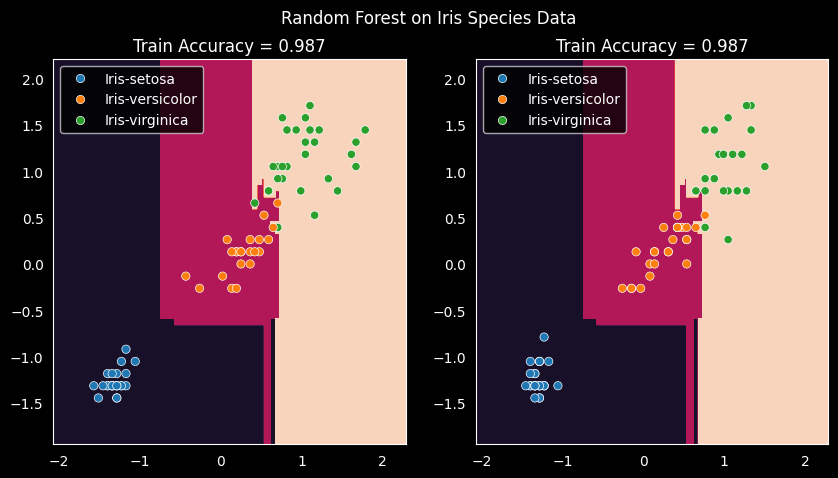

In [5]:
rf = RandomForestClassifier(n_estimators=6, random_state=67)
rf.fit(X_train, Y_train)

xx, yy = np.meshgrid(
    np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 1000),
    np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 1000),
)
grid_inputs = np.c_[xx.ravel(), yy.ravel()]
grid_outputs = rf.predict(grid_inputs)
grid_outputs = grid_outputs.reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].contourf(xx, yy, grid_outputs)
sns.scatterplot(x=X_train[:, 0], y=X_train[:, 1], hue=le.inverse_transform(Y_train), ax=axes[0])
axes[0].set_title(f"Train Accuracy = {accuracy_score(Y_train, rf.predict(X_train)):.3f}")

axes[1].contourf(xx, yy, grid_outputs)
sns.scatterplot(x=X_test[:, 0], y=X_test[:, 1], hue=le.inverse_transform(Y_test), ax=axes[1])
axes[1].set_title(f"Train Accuracy = {accuracy_score(Y_test, rf.predict(X_test)):.3f}")

plt.suptitle("Random Forest on Iris Species Data")

plt.show()